
# Улучшение модели 3D CNN для сервиса детекции патологических образований в легких


## Этап 1. Импорт библиотек

In [12]:

import os
import glob
import random

import pandas as pd
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    fbeta_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)



## Этап 2. Загрузка таблиц



In [13]:

data_path = "/Users/aidungmas/Desktop/MFDP/Dataset"

annotations = pd.read_csv("annotations.csv")              
candidates = pd.read_csv("candidates_V2.csv")              
sample_submission = pd.read_csv("sampleSubmission.csv")    



### Проверка данных


In [14]:

print("annotations:", annotations.shape)
print("candidates:", candidates.shape)
print("sample_submission:", sample_submission.shape)
print()
print(candidates["class"].value_counts())


annotations: (1186, 5)
candidates: (754975, 5)
sample_submission: (8, 5)

class
0    753418
1      1557
Name: count, dtype: int64



## Этап 3. Предобработка и генерация 3D-патчей

Класс `LunaDataset`:

- находит соответствующее КТ по `seriesuid`;
- переводит координаты кандидата в воксель;
- извлекает кубический патч `32 × 32 × 32`;
- ограничивает интенсивности диапазоном от −1000 до 400 HU;
- нормализует интенсивности в диапазон `[0, 1]`;
- при обучении выполняет случайные отражения патча;


In [15]:

class LunaDataset(Dataset):
    def __init__(
        self,
        annotations,
        candidates,
        data_path,
        series_ids=None,
        patch_size=32,
        max_negatives=None,
        augment=False
    ):
        self.annotations = annotations.copy()
        self.candidates = candidates.copy()
        self.data_path = data_path
        self.series_ids = series_ids
        self.patch_size = patch_size
        self.augment = augment

        self.all_mhd_paths = glob.glob(
            os.path.join(self.data_path, "subset*", "*.mhd")
        )

        self.scan_path_dict = {}

        for path in self.all_mhd_paths:
            scan_name = os.path.basename(path).replace(".mhd", "")
            self.scan_path_dict[scan_name] = path

        positive = self.annotations.copy()
        positive["class"] = 1

        negative = self.candidates[self.candidates["class"] == 0].copy()

        if series_ids is not None:
            positive = positive[positive["seriesuid"].isin(series_ids)].copy()
            negative = negative[negative["seriesuid"].isin(series_ids)].copy()

        if max_negatives is not None and len(negative) > max_negatives:
            negative = negative.sample(
                n=max_negatives,
                random_state=42
            ).copy()

        self.samples = pd.concat(
            [
                positive[["seriesuid", "coordX", "coordY", "coordZ", "class"]],
                negative[["seriesuid", "coordX", "coordY", "coordZ", "class"]]
            ],
            ignore_index=True
        )

        self.samples = self.samples.sample(
            frac=1,
            random_state=42
        ).reset_index(drop=True)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples.iloc[idx]

        scan_id = sample["seriesuid"]

        world_coord = np.array([
            sample["coordX"],
            sample["coordY"],
            sample["coordZ"]
        ])

        label = int(sample["class"])

        scan_path = self.find_scan_path(scan_id)

        image, spacing, origin = self.load_scan(scan_path)

        spacing = np.array(spacing)
        origin = np.array(origin)

        voxel = np.round((world_coord - origin) / spacing).astype(int)
        voxel = voxel[::-1]

        patch = self.get_patch(image, voxel, self.patch_size)

        if self.augment:
            patch = self.augment_patch(patch)

        patch = np.expand_dims(patch, axis=0)
        patch = np.ascontiguousarray(patch)

        patch = torch.tensor(patch, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        return patch, label

    def find_scan_path(self, scan_id):
        if scan_id in self.scan_path_dict:
            return self.scan_path_dict[scan_id]

        raise FileNotFoundError(f"{scan_id} not found")

    def load_scan(self, path):
        itkimage = sitk.ReadImage(path)
        image = sitk.GetArrayFromImage(itkimage).astype(np.float32)

        image = np.clip(image, -1000, 400)
        image = (image + 1000) / 1400

        spacing = itkimage.GetSpacing()
        origin = itkimage.GetOrigin()

        return image, spacing, origin

    def get_patch(self, image, voxel, size):
        z, y, x = voxel
        half = size // 2

        patch = np.zeros((size, size, size), dtype=image.dtype)

        z_min, z_max = z - half, z + half
        y_min, y_max = y - half, y + half
        x_min, x_max = x - half, x + half

        img_z_min = max(z_min, 0)
        img_z_max = min(z_max, image.shape[0])

        img_y_min = max(y_min, 0)
        img_y_max = min(y_max, image.shape[1])

        img_x_min = max(x_min, 0)
        img_x_max = min(x_max, image.shape[2])

        if img_z_min >= img_z_max or img_y_min >= img_y_max or img_x_min >= img_x_max:
            return patch

        patch_z_min = img_z_min - z_min
        patch_y_min = img_y_min - y_min
        patch_x_min = img_x_min - x_min

        patch_z_max = patch_z_min + (img_z_max - img_z_min)
        patch_y_max = patch_y_min + (img_y_max - img_y_min)
        patch_x_max = patch_x_min + (img_x_max - img_x_min)

        patch[
            patch_z_min:patch_z_max,
            patch_y_min:patch_y_max,
            patch_x_min:patch_x_max
        ] = image[
            img_z_min:img_z_max,
            img_y_min:img_y_max,
            img_x_min:img_x_max
        ]

        return patch

    def augment_patch(self, patch):
        if random.random() < 0.5:
            patch = np.flip(patch, axis=1)

        if random.random() < 0.5:
            patch = np.flip(patch, axis=2)

        return patch.copy()



## Этап 4. Разделение на train и validation

Разделение выполняется по `seriesuid`, чтобы не было перекреста кандидатов в датасете.


In [16]:

all_mhd_paths = glob.glob(
    os.path.join(data_path, "subset*", "*.mhd")
)

all_series_ids = [
    os.path.basename(path).replace(".mhd", "")
    for path in all_mhd_paths
]

positive_series = set(annotations["seriesuid"])

stratify_labels = [
    int(series_id in positive_series)
    for series_id in all_series_ids
]

train_series_ids, val_series_ids = train_test_split(
    all_series_ids,
    test_size=0.2,
    random_state=42,
    stratify=stratify_labels
)

train_dataset = LunaDataset(
    annotations=annotations,
    candidates=candidates,
    data_path=data_path,
    series_ids=train_series_ids,
    patch_size=32,
    max_negatives=4000,
    augment=True
)

val_dataset = LunaDataset(
    annotations=annotations,
    candidates=candidates,
    data_path=data_path,
    series_ids=val_series_ids,
    patch_size=32,
    max_negatives=1000,
    augment=False
)

print("train:", len(train_dataset))
print("val:", len(val_dataset))


train: 4933
val: 1253



## Этап 5. Формирование DataLoader

`DataLoader` объединяет патчи в батчи и перемешивание для обучающей выборки.


In [17]:

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

for batch_X, batch_y in train_loader:
    print("Размер батча:", batch_X.shape)
    print("Метки:", batch_y)
    break


Размер батча: torch.Size([8, 1, 32, 32, 32])
Метки: tensor([0, 1, 0, 1, 0, 0, 1, 0])



## Этап 6. Архитектура модели

В ноутбуке реализованы две архитектуры моделей.

### Исходная модель `Simple3DCNN`

Исходная модель состоит из:

- двух трёхмерных свёрточных слоёв `Conv3d`;
- функции активации `ReLU` после каждого свёрточного слоя;
- двух слоёв `MaxPool3d` для уменьшения пространственного размера патча;
- слоя `Flatten` для преобразования трёхмерных карт признаков в одномерный вектор;
- двух полносвязных слоёв `Linear`;


### Улучшенная модель Improved3DCNN

В улучшенной модели:

- добавлен третий свёрточный слой;
- количество каналов признаков последовательно увеличивается с 8 до 32;
- после свёрточных слоёв используется GroupNorm, которая стабильнее работает при небольшом размере батча;
- вместо обычной ReLU применяется LeakyReLU, которая сохраняет небольшой градиент для отрицательных значений;
- после трёх операций MaxPool3d размер карт признаков уменьшается с 32 × 32 × 32 до 4 × 4 × 4, что позволяет модели учитывать не только наличие признаков, но и их расположение и распределение внутри трёхмерного патча.;
- добавлен Dropout со значением 0.2 для снижения риска переобучения.

In [2]:

class Simple3DCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv3d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(2),

            nn.Conv3d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 8 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x


class Improved3DCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            # 32 × 32 × 32
            nn.Conv3d(1, 8, kernel_size=3, padding=1),
            nn.GroupNorm(4, 8),
            nn.LeakyReLU(0.1),

            nn.Conv3d(8, 8, kernel_size=3, padding=1),
            nn.GroupNorm(4, 8),
            nn.LeakyReLU(0.1),

            nn.MaxPool3d(2),  # 16 × 16 × 16

            nn.Conv3d(8, 16, kernel_size=3, padding=1),
            nn.GroupNorm(4, 16),
            nn.LeakyReLU(0.1),

            nn.Conv3d(16, 16, kernel_size=3, padding=1),
            nn.GroupNorm(4, 16),
            nn.LeakyReLU(0.1),

            nn.MaxPool3d(2),  # 8 × 8 × 8

            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.GroupNorm(8, 32),
            nn.LeakyReLU(0.1),

            nn.MaxPool3d(2)   # 4 × 4 × 4
        )

        self.fc = nn.Sequential(
            nn.Flatten(),

            # Сохраняем пространственные признаки 4 × 4 × 4,
            # а не сжимаем весь патч до 1 × 1 × 1
            nn.Linear(32 * 4 * 4 * 4, 128),
            nn.LeakyReLU(0.1),

            nn.Dropout(0.2),

            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)

        return x

NameError: name 'nn' is not defined


## Этап 7. Обучение и расчёт метрик

На каждой эпохе рассчитываются:

- **F1** — баланс precision и recall;
- **F2** — метрика с повышенным весом полноты обнаружения патологических узлов;
- **FPR** — доля ложноположительных срабатываний;
- TP, FP, FN и TN.


In [23]:

class Trainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, device="cpu"):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        self.history = []

        self.model.to(self.device)

    def train_one_epoch(self):
        self.model.train()
        total_loss = 0

        for batch_X, batch_y in self.train_loader:
            batch_X = batch_X.to(self.device)
            batch_y = batch_y.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(batch_X)
            loss = self.criterion(outputs, batch_y)

            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

        return total_loss / len(self.train_loader)

    def predict_proba(self):
        self.model.eval()

        all_probabilities = []
        all_true = []

        with torch.no_grad():
            for batch_X, batch_y in self.val_loader:
                batch_X = batch_X.to(self.device)

                outputs = self.model(batch_X)
                probabilities = torch.softmax(outputs, dim=1)[:, 1]

                all_probabilities.extend(probabilities.cpu().numpy())
                all_true.extend(batch_y.numpy())

        return np.array(all_true), np.array(all_probabilities)

    def evaluate(self, threshold=0.5):
        all_true, all_probabilities = self.predict_proba()
        all_preds = (all_probabilities >= threshold).astype(int)

        f1 = f1_score(all_true, all_preds, zero_division=0)
        f2 = fbeta_score(all_true, all_preds, beta=2, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(
            all_true,
            all_preds,
            labels=[0, 1]
        ).ravel()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        return f1, f2, fpr, tp, fp, fn, tn

    def train(self, num_epochs):
        for epoch in range(num_epochs):
            loss = self.train_one_epoch()
            f1, f2, fpr, tp, fp, fn, tn = self.evaluate()

            self.history.append({
                "epoch": epoch + 1,
                "loss": loss,
                "f1": f1,
                "f2": f2,
                "fpr": fpr,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "tn": tn
            })

            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"loss: {loss:.3f} | "
                f"F1: {f1:.4f} | "
                f"F2: {f2:.4f} | "
                f"FPR: {fpr:.4f} | "
                f"TP: {tp} FP: {fp} FN: {fn} TN: {tn}"
            )

        return pd.DataFrame(self.history)



## Этап 8. Настройка функции потерь и оптимизатора

В обучающей выборке отрицательных кандидатов больше, чем кандидатов с выявлеными патологическими узлами. Чтобы модель не отдавала предпочтение более распространённому классу 0, ошибки в классе с патологическими узлами получают больший вес.


In [34]:
class_counts = (
    train_dataset.samples["class"]
    .value_counts()
    .sort_index()
)

class_weights = len(train_dataset) / (2 * class_counts.values)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Количество объектов по классам:")
print(class_counts)

print("Веса классов:")
print(class_weights)


Количество объектов по классам:
class
0    4000
1     933
Name: count, dtype: int64
Веса классов:
tensor([0.6166, 2.6436])


## Этап 9. Обучение моделей

In [20]:
#Простая модель
simple_model = Simple3DCNN()

simple_optimizer = torch.optim.Adam(
    simple_model.parameters(),
    lr=0.001
)

simple_trainer = Trainer(
    model=simple_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=simple_optimizer,
    device="cpu"
)

simple_history = simple_trainer.train(num_epochs=10)

Epoch 1/10 | loss: 0.645 | F1: 0.5023 | F2: 0.6728 | FPR: 0.4030 | TP: 220 FP: 403 FN: 33 TN: 597
Epoch 2/10 | loss: 0.533 | F1: 0.6422 | F2: 0.7256 | FPR: 0.1720 | TP: 201 FP: 172 FN: 52 TN: 828
Epoch 3/10 | loss: 0.446 | F1: 0.6993 | F2: 0.7361 | FPR: 0.1060 | TP: 193 FP: 106 FN: 60 TN: 894
Epoch 4/10 | loss: 0.380 | F1: 0.7736 | F2: 0.7249 | FPR: 0.0260 | TP: 176 FP: 26 FN: 77 TN: 974
Epoch 5/10 | loss: 0.350 | F1: 0.7877 | F2: 0.7401 | FPR: 0.0240 | TP: 180 FP: 24 FN: 73 TN: 976
Epoch 6/10 | loss: 0.296 | F1: 0.7773 | F2: 0.7490 | FPR: 0.0380 | TP: 185 FP: 38 FN: 68 TN: 962
Epoch 7/10 | loss: 0.261 | F1: 0.8259 | F2: 0.8140 | FPR: 0.0370 | TP: 204 FP: 37 FN: 49 TN: 963
Epoch 8/10 | loss: 0.242 | F1: 0.8371 | F2: 0.8159 | FPR: 0.0290 | TP: 203 FP: 29 FN: 50 TN: 971
Epoch 9/10 | loss: 0.210 | F1: 0.8327 | F2: 0.8405 | FPR: 0.0470 | TP: 214 FP: 47 FN: 39 TN: 953
Epoch 10/10 | loss: 0.189 | F1: 0.8566 | F2: 0.8667 | FPR: 0.0420 | TP: 221 FP: 42 FN: 32 TN: 958


In [26]:
#Улучшенная модель
improved_model = Improved3DCNN()

improved_optimizer = torch.optim.Adam(
    improved_model.parameters(),
    lr=0.001
)

improved_trainer = Trainer(
    model=improved_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=improved_optimizer,
    device="cpu"
)

improved_history = improved_trainer.train(num_epochs=10)

Epoch 1/10 | loss: 0.608 | F1: 0.6791 | F2: 0.6602 | FPR: 0.0660 | TP: 164 FP: 66 FN: 89 TN: 934
Epoch 2/10 | loss: 0.368 | F1: 0.8347 | F2: 0.8126 | FPR: 0.0290 | TP: 202 FP: 29 FN: 51 TN: 971
Epoch 3/10 | loss: 0.261 | F1: 0.8351 | F2: 0.8846 | FPR: 0.0720 | TP: 233 FP: 72 FN: 20 TN: 928
Epoch 4/10 | loss: 0.197 | F1: 0.8566 | F2: 0.8873 | FPR: 0.0540 | TP: 230 FP: 54 FN: 23 TN: 946
Epoch 5/10 | loss: 0.168 | F1: 0.8773 | F2: 0.9098 | FPR: 0.0490 | TP: 236 FP: 49 FN: 17 TN: 951
Epoch 6/10 | loss: 0.161 | F1: 0.9012 | F2: 0.9012 | FPR: 0.0250 | TP: 228 FP: 25 FN: 25 TN: 975
Epoch 7/10 | loss: 0.152 | F1: 0.8571 | F2: 0.8966 | FPR: 0.0590 | TP: 234 FP: 59 FN: 19 TN: 941
Epoch 8/10 | loss: 0.138 | F1: 0.8959 | F2: 0.9291 | FPR: 0.0440 | TP: 241 FP: 44 FN: 12 TN: 956
Epoch 9/10 | loss: 0.116 | F1: 0.8993 | F2: 0.9305 | FPR: 0.0420 | TP: 241 FP: 42 FN: 12 TN: 958
Epoch 10/10 | loss: 0.118 | F1: 0.9270 | F2: 0.9281 | FPR: 0.0190 | TP: 235 FP: 19 FN: 18 TN: 981



## Этап 10. Сравнение обучения двух моделей

На графиках сравнивается изменение функции потерь и метрик F1, F2 и FPR по эпохам для исходной модели `Simple3DCNN` и улучшенной модели `Improved3DCNN`.

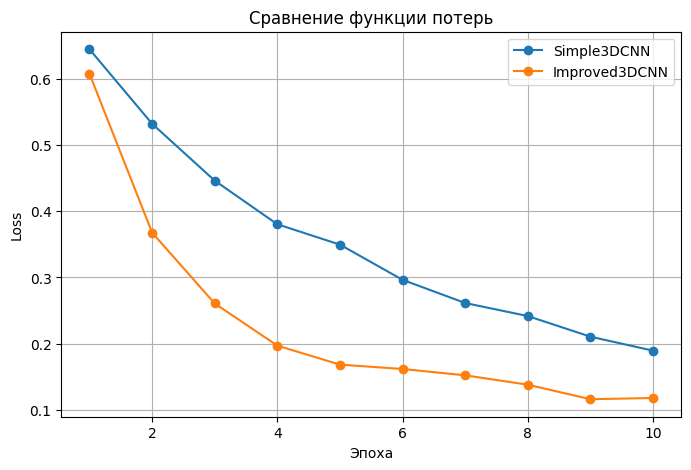

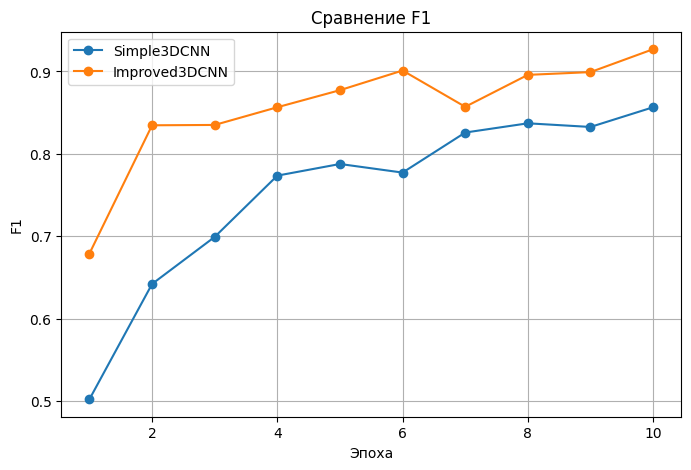

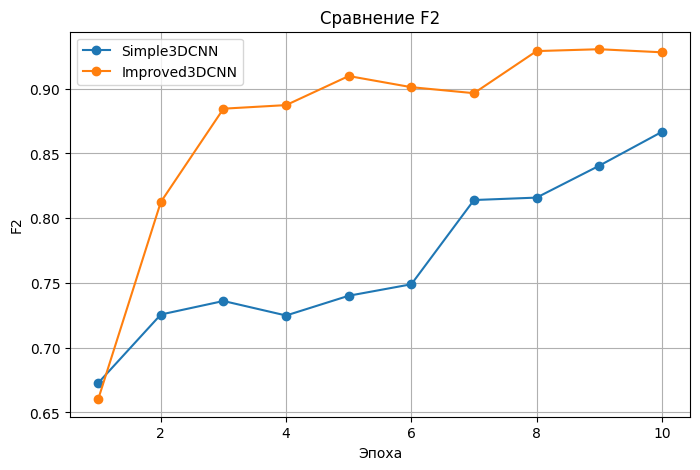

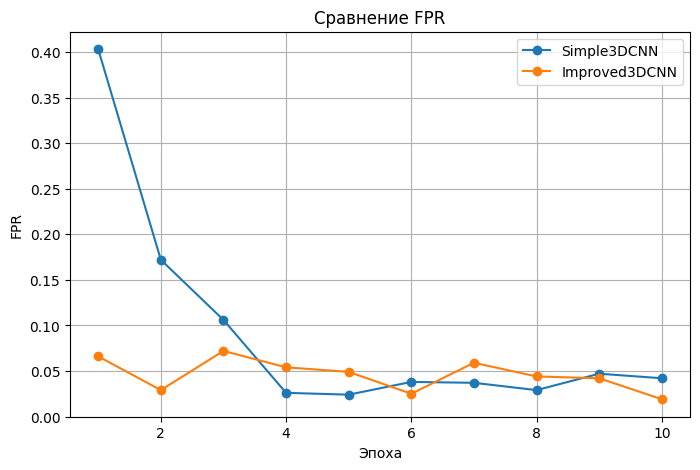

Исходная модель Simple3DCNN


,epoch,loss,f1,f2,fpr,tp,fp,fn,tn
0,1,0.645288,0.502283,0.672783,0.403,220,403,33,597
1,2,0.532539,0.642173,0.725632,0.172,201,172,52,828
2,3,0.446453,0.699275,0.736079,0.106,193,106,60,894
3,4,0.380446,0.773626,0.724876,0.026,176,26,77,974
4,5,0.349620,0.787746,0.740132,0.024,180,24,73,976
5,6,0.296335,0.777311,0.748988,0.038,185,38,68,962
6,7,0.261282,0.825911,0.814046,0.037,204,37,49,963
7,8,0.241547,0.837113,0.815916,0.029,203,29,50,971
8,9,0.210348,0.832685,0.840534,0.047,214,47,39,953
9,10,0.189173,0.856589,0.866667,0.042,221,42,32,958


Улучшенная модель Improved3DCNN


,epoch,loss,f1,f2,fpr,tp,fp,fn,tn
0,1,0.608277,0.679089,0.660225,0.066,164,66,89,934
1,2,0.367838,0.834711,0.812550,0.029,202,29,51,971
2,3,0.260569,0.835125,0.884586,0.072,233,72,20,928
3,4,0.196804,0.856611,0.887346,0.054,230,54,23,946
4,5,0.168067,0.877323,0.909792,0.049,236,49,17,951
5,6,0.161465,0.901186,0.901186,0.025,228,25,25,975
6,7,0.151869,0.857143,0.896552,0.059,234,59,19,941
7,8,0.137683,0.895911,0.929067,0.044,241,44,12,956
8,9,0.115722,0.899254,0.930502,0.042,241,42,12,958
9,10,0.117572,0.927022,0.928120,0.019,235,19,18,981


In [27]:

# График функции потерь для двух моделей

plt.figure(figsize=(8, 5))

plt.plot(
    simple_history["epoch"],
    simple_history["loss"],
    marker="o",
    label="Simple3DCNN"
)

plt.plot(
    improved_history["epoch"],
    improved_history["loss"],
    marker="o",
    label="Improved3DCNN"
)

plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Сравнение функции потерь")
plt.legend()
plt.grid()
plt.show()


# График F1 для двух моделей

plt.figure(figsize=(8, 5))

plt.plot(
    simple_history["epoch"],
    simple_history["f1"],
    marker="o",
    label="Simple3DCNN"
)

plt.plot(
    improved_history["epoch"],
    improved_history["f1"],
    marker="o",
    label="Improved3DCNN"
)

plt.xlabel("Эпоха")
plt.ylabel("F1")
plt.title("Сравнение F1")
plt.legend()
plt.grid()
plt.show()


# График F2 для двух моделей

plt.figure(figsize=(8, 5))

plt.plot(
    simple_history["epoch"],
    simple_history["f2"],
    marker="o",
    label="Simple3DCNN"
)

plt.plot(
    improved_history["epoch"],
    improved_history["f2"],
    marker="o",
    label="Improved3DCNN"
)

plt.xlabel("Эпоха")
plt.ylabel("F2")
plt.title("Сравнение F2")
plt.legend()
plt.grid()
plt.show()


# График FPR для двух моделей

plt.figure(figsize=(8, 5))

plt.plot(
    simple_history["epoch"],
    simple_history["fpr"],
    marker="o",
    label="Simple3DCNN"
)

plt.plot(
    improved_history["epoch"],
    improved_history["fpr"],
    marker="o",
    label="Improved3DCNN"
)

plt.xlabel("Эпоха")
plt.ylabel("FPR")
plt.title("Сравнение FPR")
plt.legend()
plt.grid()
plt.show()


# Итоговые значения по эпохам

print("Исходная модель Simple3DCNN")
display(simple_history)

print("Улучшенная модель Improved3DCNN")
display(improved_history)


## Этап 11. Постобработка предсказаний и подбор порога

Оптимальный порог выбирается по максимальному F2; при равном F2 предпочтение отдаётся меньшему FPR. (берется F2 так как она больше штрафует за FN, что критично для медицинского сервиса)


In [31]:


model = improved_model
trainer = improved_trainer
history = improved_history


all_true, all_probabilities = trainer.predict_proba()

threshold_results = []

for threshold in np.arange(0.1, 0.91, 0.05):
    predictions = (
        all_probabilities >= threshold
    ).astype(int)

    f1 = f1_score(
        all_true,
        predictions,
        zero_division=0
    )

    f2 = fbeta_score(
        all_true,
        predictions,
        beta=2,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        all_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "f1": f1,
        "f2": f2,
        "fpr": fpr,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })


threshold_results = pd.DataFrame(
    threshold_results
)

best_result = (
    threshold_results
    .sort_values(
        ["f2", "fpr"],
        ascending=[False, True]
    )
    .iloc[0]
)

threshold_results

,threshold,f1,f2,fpr,tp,fp,fn,tn
0,0.10,0.859619,0.928144,0.076,248,76,5,924
1,0.15,0.881295,0.931559,0.058,245,58,8,942
2,0.20,0.893773,0.934866,0.049,244,49,9,951
3,0.25,0.910448,0.942085,0.039,244,39,9,961
4,0.30,0.914934,0.939441,0.034,242,34,11,966
5,0.35,0.916350,0.937743,0.032,241,32,12,968
6,0.40,0.921606,0.939938,0.029,241,29,12,971
7,0.45,0.930502,0.943618,0.024,241,24,12,976
8,0.50,0.927022,0.928120,0.019,235,19,18,981
9,0.55,0.926733,0.925633,0.018,234,18,19,982


## Этап 12. Итоговая оценка качества

Оптимальный порог: 0.45
F1: 0.9305
F2: 0.9436
FPR: 0.024
TP: 241 FP: 24 FN: 12 TN: 976


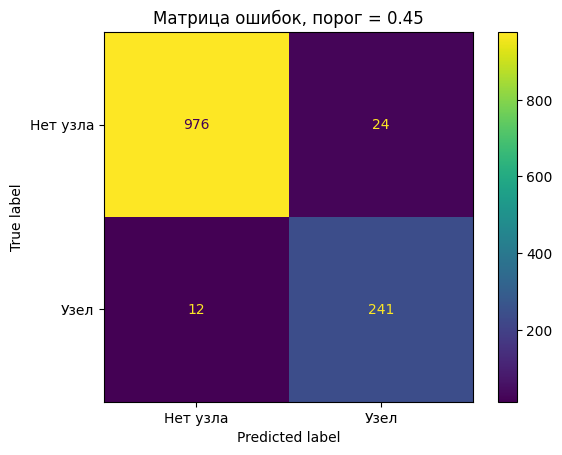

In [32]:

best_threshold = best_result["threshold"]
final_predictions = (all_probabilities >= best_threshold).astype(int)

print("Оптимальный порог:", best_threshold)
print("F1:", round(best_result["f1"], 4))
print("F2:", round(best_result["f2"], 4))
print("FPR:", round(best_result["fpr"], 4))
print(
    "TP:", int(best_result["tp"]),
    "FP:", int(best_result["fp"]),
    "FN:", int(best_result["fn"]),
    "TN:", int(best_result["tn"])
)

ConfusionMatrixDisplay.from_predictions(
    all_true,
    final_predictions,
    display_labels=["Нет узла", "Узел"],
    values_format="d"
)
plt.title(f"Матрица ошибок, порог = {best_threshold:.2f}")
plt.show()



## Вывод

В работе были обучены и сопоставлены две модели классификации КТ-сканов: исходная `Simple3DCNN` и улучшенная `Improved3DCNN`.

Разделение данных выполнялось по `seriesuid`, чтобы избежать одновременное попадание кандидатов в обучающую и валидационную выборки. Для учёта дисбаланса классов использовалась взвешенная функция потерь.

На 10-й эпохе исходная модель показала:

- F1 = 0.8566;
- F2 = 0.8667;
- FPR = 0.0420;
- TP = 221;
- FP = 42;
- FN = 32;
- TN = 958.

Улучшенная модель при стандартном пороге 0.5 показала:

- F1 = 0.9270;
- F2 = 0.9281;
- FPR = 0.0190;
- TP = 235;
- FP = 19;
- FN = 18;
- TN = 981.

После подбора порога на валидационной выборке оптимальным оказался порог 0.45. При этом были получены:

- F1 = 0.9305;
- F2 = 0.9436;
- FPR = 0.0240;
- TP = 241;
- FP = 24;
- FN = 12;
- TN = 976.

По сравнению с исходной моделью улучшенная архитектура повысила F1 и F2, уменьшила количество пропущенных положительных кандидатов и снизила долю ложноположительных срабатываний. Для дальнейшего использования выбрана модель `Improved3DCNN` с порогом классификации 0.45.

In [33]:
# Сохранение весов улучшенной модели

checkpoint = {
    "model_state_dict": {
        name: parameter.cpu()
        for name, parameter in improved_model.state_dict().items()
    },
    "threshold": float(best_threshold),
    "model_name": "Improved3DCNN",
    "patch_size": 32,
    "f1": float(best_result["f1"]),
    "f2": float(best_result["f2"]),
    "fpr": float(best_result["fpr"])
}

torch.save(
    checkpoint,
    "improved_3dcnn_checkpoint.pth"
)

print("Модель сохранена: improved_3dcnn_checkpoint.pth")

Модель сохранена: improved_3dcnn_checkpoint.pth
